In [2]:
import pandas as pd
df = pd.read_csv("../data/raw/borg_traces_data.csv", nrows=100000)
print(df.shape)
print(df.columns)
print(df.head())

(100000, 34)
Index(['Unnamed: 0', 'time', 'instance_events_type', 'collection_id',
       'scheduling_class', 'collection_type', 'priority',
       'alloc_collection_id', 'instance_index', 'machine_id',
       'resource_request', 'constraint', 'collections_events_type', 'user',
       'collection_name', 'collection_logical_name',
       'start_after_collection_ids', 'vertical_scaling', 'scheduler',
       'start_time', 'end_time', 'average_usage', 'maximum_usage',
       'random_sample_usage', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction',
       'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution',
       'cluster', 'event', 'failed'],
      dtype='str')
   Unnamed: 0           time  instance_events_type  collection_id  \
0           0              0                     2    94591244395   
1           1  2517305308183                     2   260697606809   
2           2   195684022913                     6

In [3]:
print(df.columns)

Index(['Unnamed: 0', 'time', 'instance_events_type', 'collection_id',
       'scheduling_class', 'collection_type', 'priority',
       'alloc_collection_id', 'instance_index', 'machine_id',
       'resource_request', 'constraint', 'collections_events_type', 'user',
       'collection_name', 'collection_logical_name',
       'start_after_collection_ids', 'vertical_scaling', 'scheduler',
       'start_time', 'end_time', 'average_usage', 'maximum_usage',
       'random_sample_usage', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction',
       'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution',
       'cluster', 'event', 'failed'],
      dtype='str')


In [4]:
drop_cols = [
'Unnamed: 0',
'collection_id',
'alloc_collection_id',
'instance_index',
'machine_id',
'user',
'collection_name',
'collection_logical_name',
'start_after_collection_ids',
'constraint'
]

df = df.drop(columns=drop_cols)

print(df.columns)

Index(['time', 'instance_events_type', 'scheduling_class', 'collection_type',
       'priority', 'resource_request', 'collections_events_type',
       'vertical_scaling', 'scheduler', 'start_time', 'end_time',
       'average_usage', 'maximum_usage', 'random_sample_usage',
       'assigned_memory', 'page_cache_memory', 'cycles_per_instruction',
       'memory_accesses_per_instruction', 'sample_rate',
       'cpu_usage_distribution', 'tail_cpu_usage_distribution', 'cluster',
       'event', 'failed'],
      dtype='str')


In [5]:
df = df.fillna(0)

In [6]:
df = pd.get_dummies(df, columns=[
    'scheduling_class',
    'collection_type',
    'scheduler',
    'event'
], drop_first=True)

In [7]:
import ast
import numpy as np

def extract_mean(x):
    try:
        arr = np.array(ast.literal_eval(x))

        if len(arr) == 0:
            return 0

        return arr.mean()

    except:
        return 0


df["tail_cpu_mean"] = df["tail_cpu_usage_distribution"].apply(extract_mean)

In [8]:
print(df.columns)

Index(['time', 'instance_events_type', 'priority', 'resource_request',
       'collections_events_type', 'vertical_scaling', 'start_time', 'end_time',
       'average_usage', 'maximum_usage', 'random_sample_usage',
       'assigned_memory', 'page_cache_memory', 'cycles_per_instruction',
       'memory_accesses_per_instruction', 'sample_rate',
       'cpu_usage_distribution', 'tail_cpu_usage_distribution', 'cluster',
       'failed', 'scheduling_class_1', 'scheduling_class_2',
       'scheduling_class_3', 'collection_type_1', 'scheduler_1.0',
       'event_EVICT', 'event_FAIL', 'event_FINISH', 'event_KILL', 'event_LOST',
       'event_QUEUE', 'event_SCHEDULE', 'event_UPDATE_PENDING',
       'tail_cpu_mean'],
      dtype='str')


In [9]:
df = df.drop(columns=[
    "tail_cpu_usage_distribution"
])

print(df.shape)
print(df.head())

(100000, 33)
            time  instance_events_type  priority  \
0              0                     2       200   
1  2517305308183                     2       360   
2   195684022913                     6       103   
3              0                     2       200   
4  1810627494172                     3         0   

                                    resource_request  collections_events_type  \
0  {'cpus': 0.020660400390625, 'memory': 0.014434...                        2   
1  {'cpus': 0.00724029541015625, 'memory': 0.0013...                        2   
2  {'cpus': 0.048583984375, 'memory': 0.004165649...                        6   
3  {'cpus': 0.0704345703125, 'memory': 0.04162597...                        2   
4  {'cpus': 0.00244903564453125, 'memory': 0.0002...                        3   

   vertical_scaling     start_time       end_time  \
0               1.0   274800000000   275100000000   
1               2.0  1800713000000  1800714000000   
2               2.0    81300

In [10]:
df = df.drop(columns=["time","start_time","end_time","cluster"])

In [11]:
print(df.shape)
print(df.head())

(100000, 29)
   instance_events_type  priority  \
0                     2       200   
1                     2       360   
2                     6       103   
3                     2       200   
4                     3         0   

                                    resource_request  collections_events_type  \
0  {'cpus': 0.020660400390625, 'memory': 0.014434...                        2   
1  {'cpus': 0.00724029541015625, 'memory': 0.0013...                        2   
2  {'cpus': 0.048583984375, 'memory': 0.004165649...                        6   
3  {'cpus': 0.0704345703125, 'memory': 0.04162597...                        2   
4  {'cpus': 0.00244903564453125, 'memory': 0.0002...                        3   

   vertical_scaling                                      average_usage  \
0               1.0  {'cpus': 0.00466156005859375, 'memory': 0.0059...   
1               2.0       {'cpus': 0.0, 'memory': 9.5367431640625e-07}   
2               2.0  {'cpus': 0.024200439453125, 'memor

In [12]:
import ast

def extract_cpu(x):
    try:
        data = ast.literal_eval(x)
        return data.get("cpus", 0)
    except:
        return 0


def extract_memory(x):
    try:
        data = ast.literal_eval(x)
        return data.get("memory", 0)
    except:
        return 0

In [13]:
df["req_cpu"] = df["resource_request"].apply(extract_cpu)
df["req_memory"] = df["resource_request"].apply(extract_memory)

In [14]:
df["avg_cpu"] = df["average_usage"].apply(extract_cpu)
df["avg_memory"] = df["average_usage"].apply(extract_memory)

In [15]:
df["max_cpu"] = df["maximum_usage"].apply(extract_cpu)
df["max_memory"] = df["maximum_usage"].apply(extract_memory)

In [16]:
df = df.drop(columns=[
    "resource_request",
    "average_usage",
    "maximum_usage"
])

In [17]:
print(df.shape)
print(df.head())

(100000, 32)
   instance_events_type  priority  collections_events_type  vertical_scaling  \
0                     2       200                        2               1.0   
1                     2       360                        2               2.0   
2                     6       103                        6               2.0   
3                     2       200                        2               2.0   
4                     3         0                        3               3.0   

                               random_sample_usage  assigned_memory  \
0     {'cpus': 0.0043487548828125, 'memory': None}         0.014435   
1                    {'cpus': 0.0, 'memory': None}         0.000000   
2      {'cpus': 0.026458740234375, 'memory': None}         0.010422   
3       {'cpus': 0.05084228515625, 'memory': None}         0.041626   
4  {'cpus': 0.0003414154052734375, 'memory': None}         0.000272   

   page_cache_memory  cycles_per_instruction  memory_accesses_per_instruction  

In [18]:
import ast

def extract_cpu(x):
    try:
        data = ast.literal_eval(x)
        return data.get("cpus", 0) if data.get("cpus") is not None else 0
    except:
        return 0


def extract_memory(x):
    try:
        data = ast.literal_eval(x)
        return data.get("memory", 0) if data.get("memory") is not None else 0
    except:
        return 0

In [19]:
df["sample_cpu"] = df["random_sample_usage"].apply(extract_cpu)
df["sample_memory"] = df["random_sample_usage"].apply(extract_memory)

In [20]:
df = df.drop(columns=["random_sample_usage"])

In [21]:
print(df.shape)
print(df.head())

(100000, 33)
   instance_events_type  priority  collections_events_type  vertical_scaling  \
0                     2       200                        2               1.0   
1                     2       360                        2               2.0   
2                     6       103                        6               2.0   
3                     2       200                        2               2.0   
4                     3         0                        3               3.0   

   assigned_memory  page_cache_memory  cycles_per_instruction  \
0         0.014435           0.000415                0.000000   
1         0.000000           0.000000                0.000000   
2         0.010422           0.000235                0.939919   
3         0.041626           0.000225                1.359102   
4         0.000272           0.000010                0.000000   

   memory_accesses_per_instruction  sample_rate  \
0                         0.000000          1.0   
1            

In [22]:
df = df.astype(int, errors="ignore")

In [23]:
df.dtypes

instance_events_type                 int64
priority                             int64
collections_events_type              int64
vertical_scaling                     int64
assigned_memory                      int64
page_cache_memory                    int64
cycles_per_instruction               int64
memory_accesses_per_instruction      int64
sample_rate                          int64
cpu_usage_distribution                 str
failed                               int64
scheduling_class_1                   int64
scheduling_class_2                   int64
scheduling_class_3                   int64
collection_type_1                    int64
scheduler_1.0                        int64
event_EVICT                          int64
event_FAIL                           int64
event_FINISH                         int64
event_KILL                           int64
event_LOST                           int64
event_QUEUE                          int64
event_SCHEDULE                       int64
event_UPDAT

In [24]:
print(df["failed"].value_counts())

failed
0    77108
1    22892
Name: count, dtype: int64


In [26]:
df.select_dtypes(include="object").columns

C:\Users\Aditya Sarin\AppData\Local\Temp\ipykernel_12244\1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['cpu_usage_distribution'], dtype='str')

In [27]:
import numpy as np
import re

def extract_mean(x):
    try:
        nums = re.findall(r"[-+]?\d*\.\d+|\d+", str(x))
        nums = [float(i) for i in nums]

        if len(nums) == 0:
            return 0

        return np.mean(nums)

    except:
        return 0

In [28]:
df["cpu_mean"] = df["cpu_usage_distribution"].apply(extract_mean)

In [29]:
df = df.drop(columns=["cpu_usage_distribution"])

In [30]:
df.select_dtypes(include="object").columns

Index([], dtype='str')

In [31]:
# --------- Safety: remove any remaining object columns ---------
obj_cols = df.select_dtypes(include="object").columns

if len(obj_cols) > 0:
    print("Dropping object columns:", obj_cols)
    df = df.drop(columns=obj_cols)


# --------- Features and target ---------
X = df.drop("failed", axis=1)
y = df["failed"]


# --------- Train Test Split ---------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# --------- Random Forest Model ---------
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


# --------- Prediction ---------
pred = rf.predict(X_test)


# --------- Evaluation ---------
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

print("\nClassification Report:")
print(classification_report(y_test, pred))

Accuracy: 1.0

Confusion Matrix:
[[15422     0]
 [    0  4578]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15422
           1       1.00      1.00      1.00      4578

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



yhse

In [1]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv("../data/raw/borg_traces_data.csv", nrows=100000)
print("Original Shape:", df.shape)

drop_cols = [
'Unnamed: 0',
'collection_id',
'alloc_collection_id',
'instance_index',
'machine_id',
'user',
'collection_name',
'collection_logical_name',
'start_after_collection_ids',
'constraint'
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

def extract_cpu(x):
    try:
        data = ast.literal_eval(str(x))
        return data.get("cpus", 0)
    except:
        return 0

def extract_memory(x):
    try:
        data = ast.literal_eval(str(x))
        return data.get("memory", 0)
    except:
        return 0
    
def extract_mean(x):
    try:
        nums = re.findall(r"[-+]?\d*\.\d+|\d+", str(x))
        nums = [float(i) for i in nums]

        if len(nums) == 0:
            return 0

        return np.mean(nums)
    except:
        return 0

df["req_cpu"] = df["resource_request"].apply(extract_cpu)
df["req_memory"] = df["resource_request"].apply(extract_memory)

df["avg_cpu"] = df["average_usage"].apply(extract_cpu)
df["avg_memory"] = df["average_usage"].apply(extract_memory)

df["max_cpu"] = df["maximum_usage"].apply(extract_cpu)
df["max_memory"] = df["maximum_usage"].apply(extract_memory)

df["sample_cpu"] = df["random_sample_usage"].apply(extract_cpu)
df["sample_memory"] = df["random_sample_usage"].apply(extract_memory)

df["cpu_mean"] = df["cpu_usage_distribution"].apply(extract_mean)
df["tail_cpu_mean"] = df["tail_cpu_usage_distribution"].apply(extract_mean)

heavy_cols = [
"resource_request",
"average_usage",
"maximum_usage",
"random_sample_usage",
"cpu_usage_distribution",
"tail_cpu_usage_distribution",
"time",
"start_time",
"end_time",
"cluster"
]

df = df.drop(columns=[c for c in heavy_cols if c in df.columns], errors="ignore")

df = df.drop(columns=["event"], errors="ignore")

df = df.fillna(0)

df = pd.get_dummies(
    df,
    columns=["scheduling_class","collection_type","scheduler"],
    drop_first=True
)

df = df.astype(int, errors="ignore")

print("Cleaned Shape:", df.shape)

X = df.drop("failed", axis=1)
y = df["failed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

print("\nClassification Report:")
print(classification_report(y_test, pred))

Original Shape: (100000, 34)
Cleaned Shape: (100000, 25)

Accuracy: 1.0

Confusion Matrix:
[[15422     0]
 [    0  4578]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15422
           1       1.00      1.00      1.00      4578

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [2]:
leak_cols = [
    "instance_events_type",
    "collections_events_type"
]

df = df.drop(columns=[c for c in leak_cols if c in df.columns])

In [3]:
X = df.drop("failed", axis=1)
y = df["failed"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.834
[[12979  2443]
 [  877  3701]]
              precision    recall  f1-score   support

           0       0.94      0.84      0.89     15422
           1       0.60      0.81      0.69      4578

    accuracy                           0.83     20000
   macro avg       0.77      0.83      0.79     20000
weighted avg       0.86      0.83      0.84     20000



In [5]:
import pandas as pd

importance = rf.feature_importances_

features = X.columns

imp_df = pd.DataFrame({
    "feature": features,
    "importance": importance
})

imp_df = imp_df.sort_values("importance", ascending=False)

print(imp_df.head(10))

                   feature  importance
4   cycles_per_instruction    0.280599
0                 priority    0.169116
1         vertical_scaling    0.166457
15                cpu_mean    0.112760
18      scheduling_class_2    0.071382
21           scheduler_1.0    0.050974
17      scheduling_class_1    0.035114
6              sample_rate    0.032685
16           tail_cpu_mean    0.028953
19      scheduling_class_3    0.028719


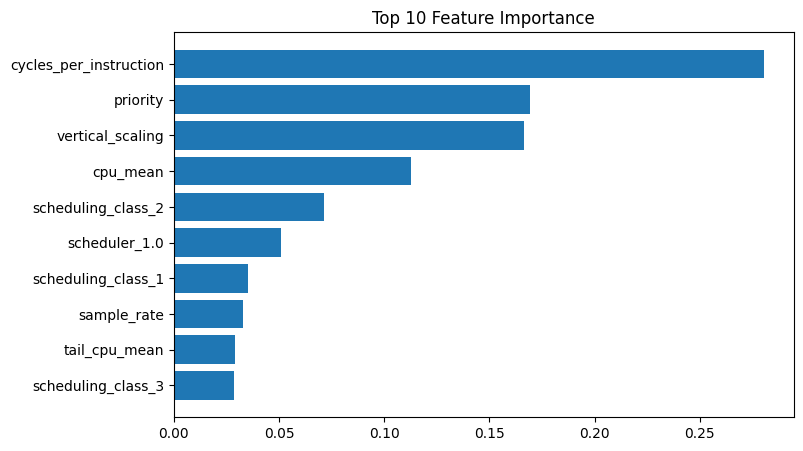

In [6]:
import matplotlib.pyplot as plt

top_features = imp_df.head(10)

plt.figure(figsize=(8,5))

plt.barh(top_features["feature"], top_features["importance"])

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance")

plt.show()

Isolation Forest

In [7]:
from sklearn.ensemble import IsolationForest

# Train anomaly detection model
iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,   # assume 5% anomalies
    random_state=42
)

iso.fit(X_train)

# anomaly prediction
anomaly_pred = iso.predict(X_test)

# convert to anomaly score
# -1 = anomaly, 1 = normal
anomaly_score = iso.decision_function(X_test)

print(anomaly_pred[:10])
print(anomaly_score[:10])

[1 1 1 1 1 1 1 1 1 1]
[0.03878105 0.07452898 0.15368716 0.13599182 0.19093963 0.10097001
 0.1573222  0.15035077 0.04000117 0.15613237]


In [8]:
failure_prob = rf.predict_proba(X_test)[:,1]

print(failure_prob[:10])

[0.         0.         0.         0.2104911  0.         0.6415379
 0.08860703 0.01203901 0.         0.        ]


In [9]:
risk_score = 0.7 * failure_prob + 0.3 * anomaly_score

print(risk_score[:10])

[0.01163431 0.02235869 0.04610615 0.18814131 0.05728189 0.47936754
 0.10922158 0.05353254 0.01200035 0.04683971]


0.28646705144317863 0.26382162315432833 0.309112479732029


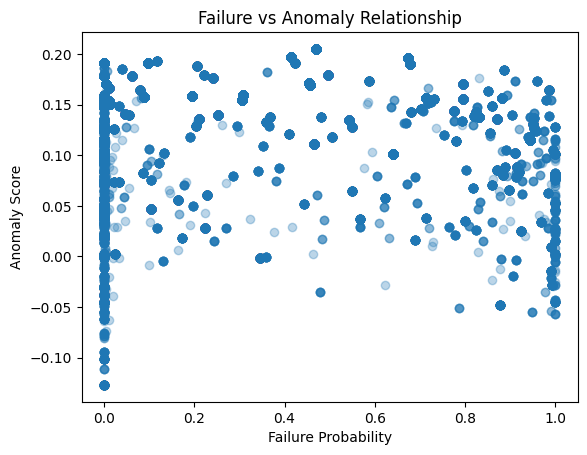

In [10]:
risk1 = 0.7 * failure_prob + 0.3 * anomaly_score
risk2 = 0.6 * failure_prob + 0.4 * anomaly_score
risk3 = 0.8 * failure_prob + 0.2 * anomaly_score

print(np.mean(risk1), np.mean(risk2), np.mean(risk3))
import matplotlib.pyplot as plt

plt.scatter(failure_prob, anomaly_score, alpha=0.3)

plt.xlabel("Failure Probability")
plt.ylabel("Anomaly Score")

plt.title("Failure vs Anomaly Relationship")

plt.show()

In [11]:
import pandas as pd

results = pd.DataFrame({
    "failure_probability": failure_prob,
    "anomaly_score": anomaly_score,
    "risk_score": risk_score
})

results.head()

,failure_probability,anomaly_score,risk_score
0,0.000000,0.038781,0.011634
1,0.000000,0.074529,0.022359
2,0.000000,0.153687,0.046106
3,0.210491,0.135992,0.188141
4,0.000000,0.190940,0.057282


In [12]:
def self_heal(risk):

    if risk > 0.60:
        return "Restart Task"

    elif risk > 0.40:
        return "Migrate VM"

    elif risk > 0.20:
        return "Scale Resources"

    else:
        return "Normal"

results["action"] = results["risk_score"].apply(self_heal)

results.head()

,failure_probability,anomaly_score,risk_score,action
0,0.000000,0.038781,0.011634,Normal
1,0.000000,0.074529,0.022359,Normal
2,0.000000,0.153687,0.046106,Normal
3,0.210491,0.135992,0.188141,Normal
4,0.000000,0.190940,0.057282,Normal


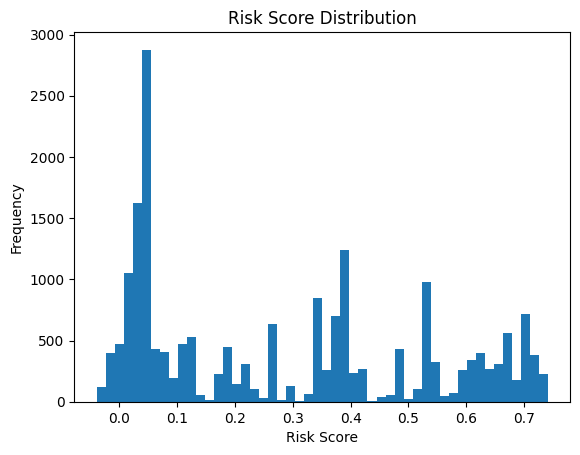

In [13]:
import matplotlib.pyplot as plt

plt.hist(results["risk_score"], bins=50)

plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")

plt.show()

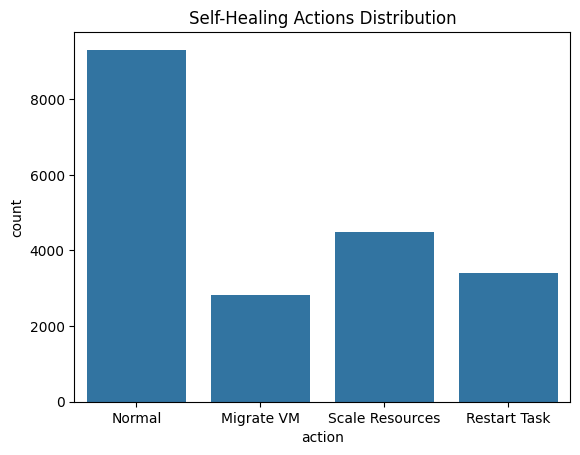

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="action", data=results)

plt.title("Self-Healing Actions Distribution")

plt.show()

In [15]:
results["action"].value_counts()

action
Normal             9308
Scale Resources    4476
Restart Task       3404
Migrate VM         2812
Name: count, dtype: int64

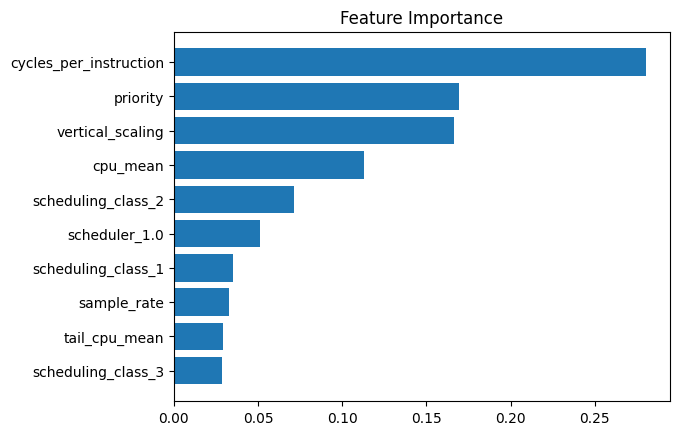

In [16]:
import matplotlib.pyplot as plt

top_features = imp_df.head(10)

plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [17]:
results["risk_level"] = pd.cut(
    results["risk_score"],
    bins=[0, 0.2, 0.4, 0.6, 1],
    labels=["Low", "Medium", "High", "Critical"]
)
results["actual"] = y_test.values
risk_analysis = results.groupby("risk_level")["actual"].mean()

print(risk_analysis)

risk_level
Low         0.015467
Medium      0.161528
High        0.390825
Critical    0.770564
Name: actual, dtype: float64


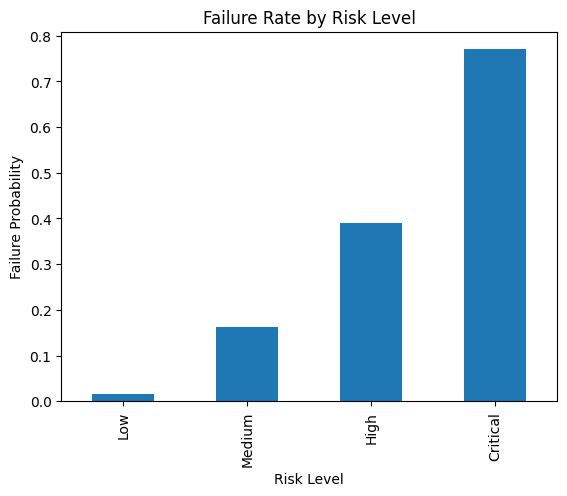

In [18]:
risk_analysis.plot(kind="bar")

plt.title("Failure Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Failure Probability")

plt.show()

In [20]:
df.head()

,priority,vertical_scaling,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,failed,req_cpu,req_memory,...,max_memory,sample_cpu,sample_memory,cpu_mean,tail_cpu_mean,scheduling_class_1,scheduling_class_2,scheduling_class_3,collection_type_1,scheduler_1.0
0,200,1,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,1,1,0
1,360,2,0,0,0,0,1,1,0,0,...,0,0,0,3,3,0,1,0,0,0
2,103,2,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,200,2,0,0,1,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,3,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [ ]:

df.columns

Index(['priority', 'vertical_scaling', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction',
       'sample_rate', 'failed', 'req_cpu', 'req_memory', 'avg_cpu',
       'avg_memory', 'max_cpu', 'max_memory', 'sample_cpu', 'sample_memory',
       'cpu_mean', 'tail_cpu_mean', 'scheduling_class_1', 'scheduling_class_2',
       'scheduling_class_3', 'collection_type_1', 'scheduler_1.0'],
      dtype='str')